# Music Collection Overview

This notebook generates a statistical report from `analysis/descriptors.jsonl`.

Outputs:
- Distribution plots for music styles, broad genres, tempo, danceability, loudness, and vocal vs instrumental.
- Key/scale plots per profile (`temperley`, `krumhansl`, `edma`) plus a compact 3-panel top-label overview.
- A final overlaid plot comparing main continuous metrics on a common 0-1 scale (min-max per metric within the collection).
- `TSV` file with full style-level results.
- Key-profile agreement statistics and concise written observations.


In [11]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Resolve project root whether notebook is run from repo root or notebooks/.
cwd = Path.cwd().resolve()
if (cwd / "analysis" / "descriptors.jsonl").exists():
    ROOT = cwd
elif (cwd.parent / "analysis" / "descriptors.jsonl").exists():
    ROOT = cwd.parent
else:
    raise FileNotFoundError("Could not locate analysis/descriptors.jsonl from current working directory")

ANALYSIS_PATH = ROOT / "analysis" / "descriptors.jsonl"
REPORT_DIR = ROOT / "analysis" / "report"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

ANALYSIS_PATH

PosixPath('/home/trekar/Descargas/musav-recommender/analysis/descriptors.jsonl')

In [12]:
rows = [json.loads(line) for line in ANALYSIS_PATH.read_text(encoding="utf-8").splitlines() if line.strip()]
len(rows)

2100

In [13]:
df = pd.DataFrame(
    {
        "relative_path": [r["relative_path"] for r in rows],
        "tempo_bpm": [r.get("tempo_bpm") for r in rows],
        "loudness_lufs": [r.get("loudness_lufs") for r in rows],
        "danceability": [
            (r.get("classifiers", {}).get("danceability_mean", [np.nan, np.nan])[1])
            for r in rows
        ],
        # Assumed output order from model: [instrumental, vocal].
        "instrumental_prob": [
            (r.get("classifiers", {}).get("voice_instrumental_mean", [np.nan, np.nan])[0])
            for r in rows
        ],
        "vocal_prob": [
            (r.get("classifiers", {}).get("voice_instrumental_mean", [np.nan, np.nan])[1])
            for r in rows
        ],
        "style_activations": [
            r.get("classifiers", {}).get("discogs400_style_activations_mean", [])
            for r in rows
        ],
        "key_temperley": [r.get("key", {}).get("temperley", {}).get("key") for r in rows],
        "scale_temperley": [r.get("key", {}).get("temperley", {}).get("scale") for r in rows],
        "key_krumhansl": [r.get("key", {}).get("krumhansl", {}).get("key") for r in rows],
        "scale_krumhansl": [r.get("key", {}).get("krumhansl", {}).get("scale") for r in rows],
        "key_edma": [r.get("key", {}).get("edma", {}).get("key") for r in rows],
        "scale_edma": [r.get("key", {}).get("edma", {}).get("scale") for r in rows],
    }
)

num_tracks = len(df)
num_tracks

2100

In [14]:
def load_style_labels(root: Path, expected_len: int) -> list[str]:
    """Load Discogs400 style labels from the official Essentia model metadata JSON."""
    meta_path = root / "models" / "genre_discogs400-discogs-effnet-1.json"
    if not meta_path.exists():
        return [f"style_{i:03d}" for i in range(expected_len)]

    meta = json.loads(meta_path.read_text(encoding="utf-8"))
    classes = meta.get("classes")
    if not isinstance(classes, list) or len(classes) != expected_len:
        got_len = len(classes) if isinstance(classes, list) else "n/a"
        raise ValueError(
            f"Unexpected classes field in {meta_path}: "
            f"expected list of length {expected_len}, got {type(classes)} len={got_len}"
        )
    return [str(x) for x in classes]


def parent_genre(label: str) -> str:
    for sep in ("---", "--", "—"):
        if sep in label:
            return label.split(sep, 1)[0].strip()
    if "-" in label and not label.startswith("style_"):
        return label.split("-", 1)[0].strip()
    return "unknown"


style_dim = len(df["style_activations"].iloc[0])
style_labels = load_style_labels(ROOT, style_dim)

style_matrix = np.vstack(df["style_activations"].to_numpy())
style_top1_idx = style_matrix.argmax(axis=1)
style_top1_label = [style_labels[i] for i in style_top1_idx]

df["style_top1"] = style_top1_label
df["broad_genre_top1"] = [parent_genre(s) for s in style_top1_label]

STYLE_THRESHOLD = 0.10
style_binary = (style_matrix >= STYLE_THRESHOLD).astype(int)

style_stats = pd.DataFrame(
    {
        "style_id": np.arange(style_dim),
        "style_label": style_labels,
        "broad_genre": [parent_genre(s) for s in style_labels],
        "mean_activation": style_matrix.mean(axis=0),
        "top1_count": np.bincount(style_top1_idx, minlength=style_dim),
        "tracks_above_threshold": style_binary.sum(axis=0),
    }
).sort_values("tracks_above_threshold", ascending=False)

style_tsv_path = REPORT_DIR / "styles_distribution.tsv"
style_stats.to_csv(style_tsv_path, sep="\t", index=False)
style_tsv_path

PosixPath('/home/trekar/Descargas/musav-recommender/analysis/report/styles_distribution.tsv')

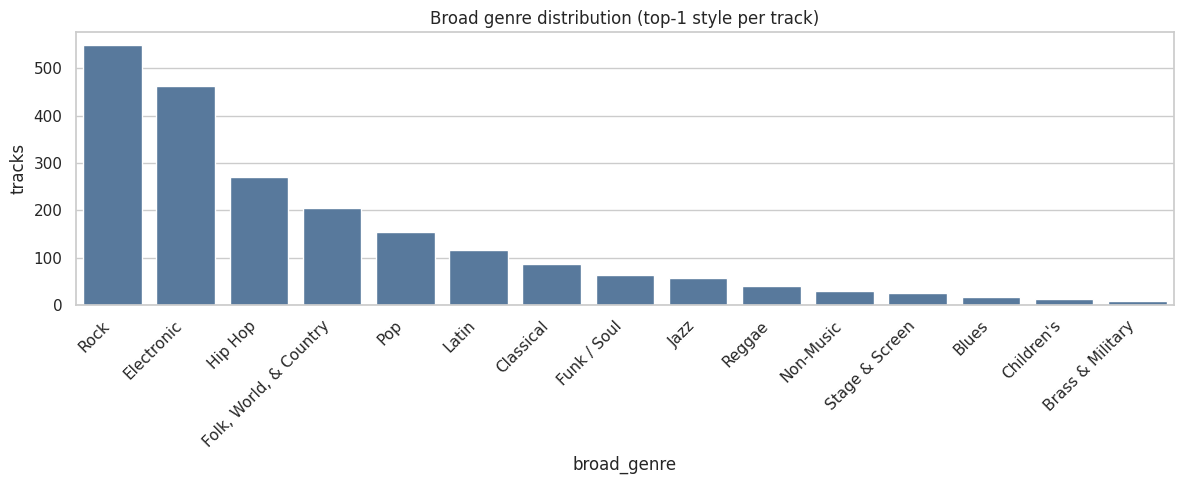

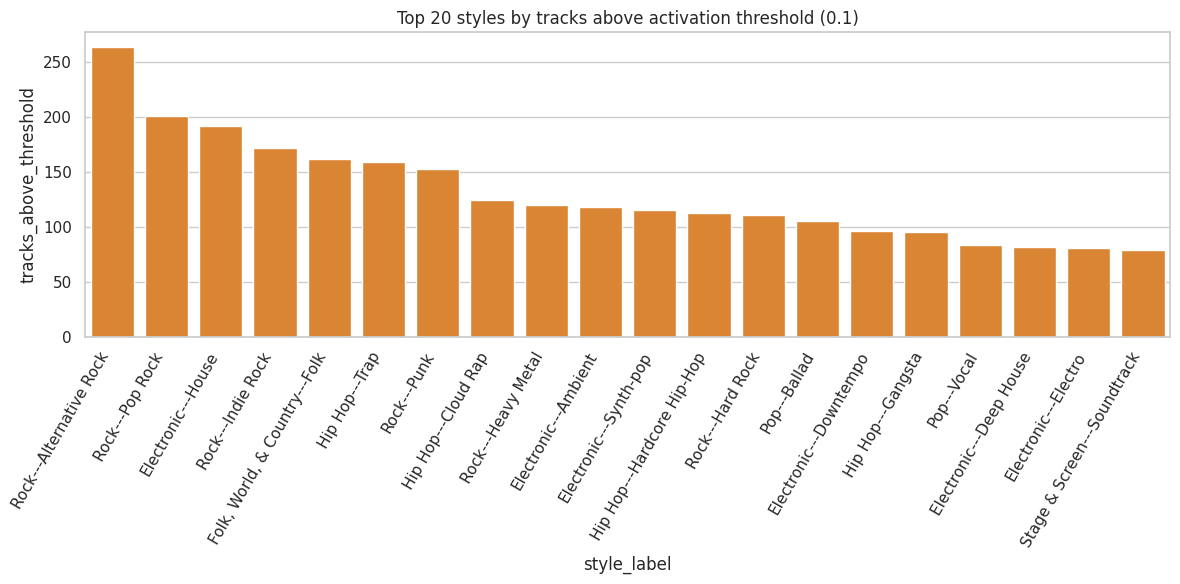

In [15]:
broad_counts = (
    df["broad_genre_top1"].value_counts().rename_axis("broad_genre").reset_index(name="tracks")
)

plt.figure(figsize=(12, 5))
sns.barplot(data=broad_counts, x="broad_genre", y="tracks", color="#4C78A8")
plt.xticks(rotation=45, ha="right")
plt.title("Broad genre distribution (top-1 style per track)")
plt.tight_layout()
plt.show()

style_top20 = style_stats.head(20)
plt.figure(figsize=(12, 6))
sns.barplot(data=style_top20, x="style_label", y="tracks_above_threshold", color="#F58518")
plt.xticks(rotation=60, ha="right")
plt.title(f"Top 20 styles by tracks above activation threshold ({STYLE_THRESHOLD})")
plt.tight_layout()
plt.show()

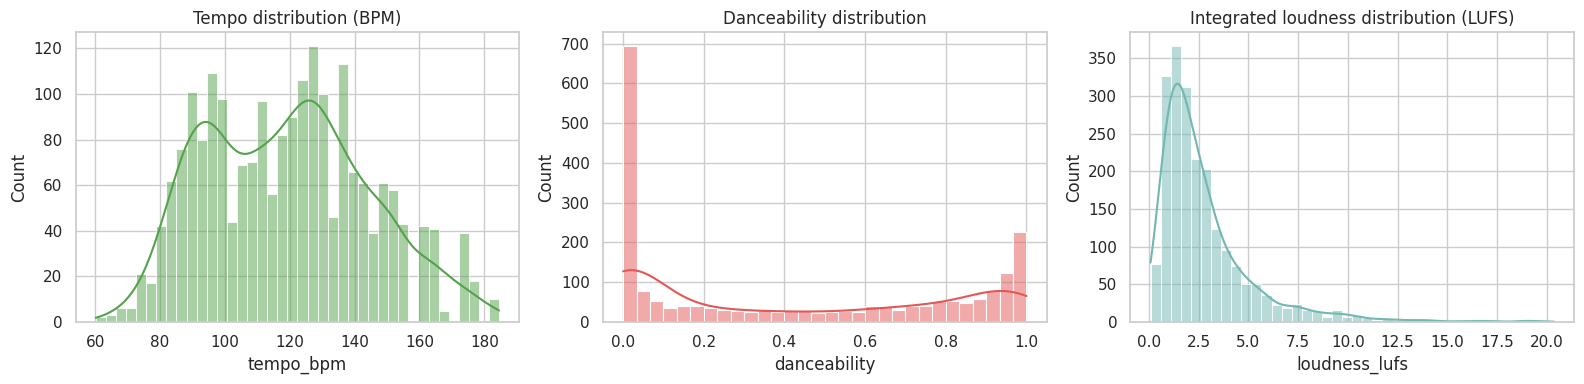

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df["tempo_bpm"].dropna(), bins=40, kde=True, ax=axes[0], color="#54A24B")
axes[0].set_title("Tempo distribution (BPM)")

sns.histplot(df["danceability"].dropna(), bins=30, kde=True, ax=axes[1], color="#E45756")
axes[1].set_title("Danceability distribution")

sns.histplot(df["loudness_lufs"].dropna(), bins=40, kde=True, ax=axes[2], color="#72B7B2")
axes[2].set_title("Integrated loudness distribution (LUFS)")

plt.tight_layout()
plt.show()

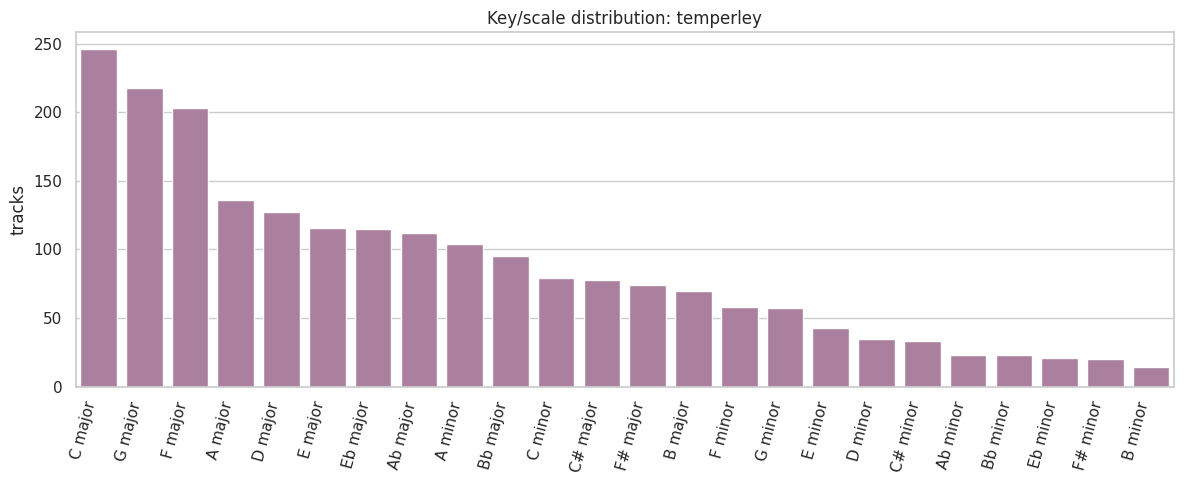

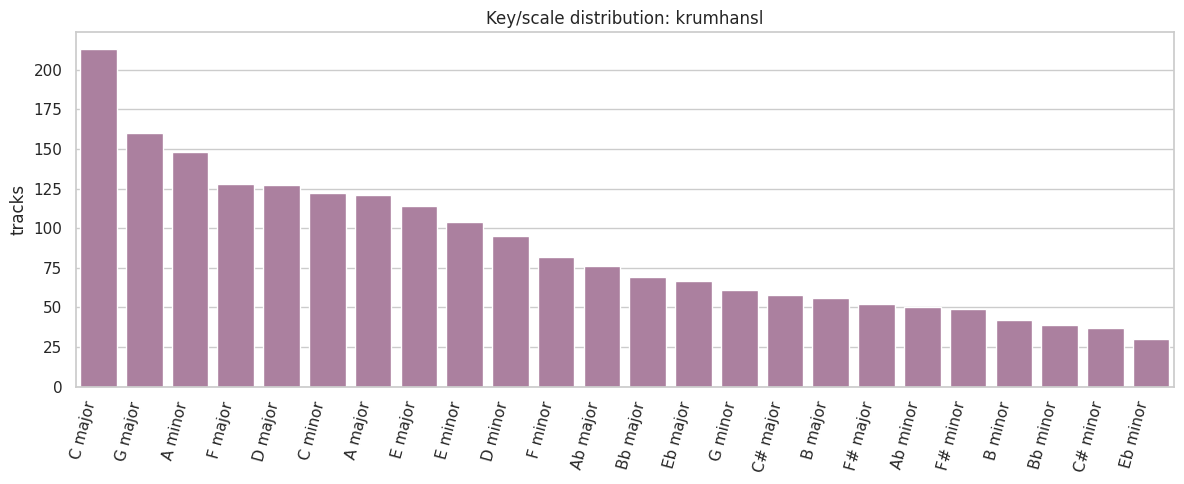

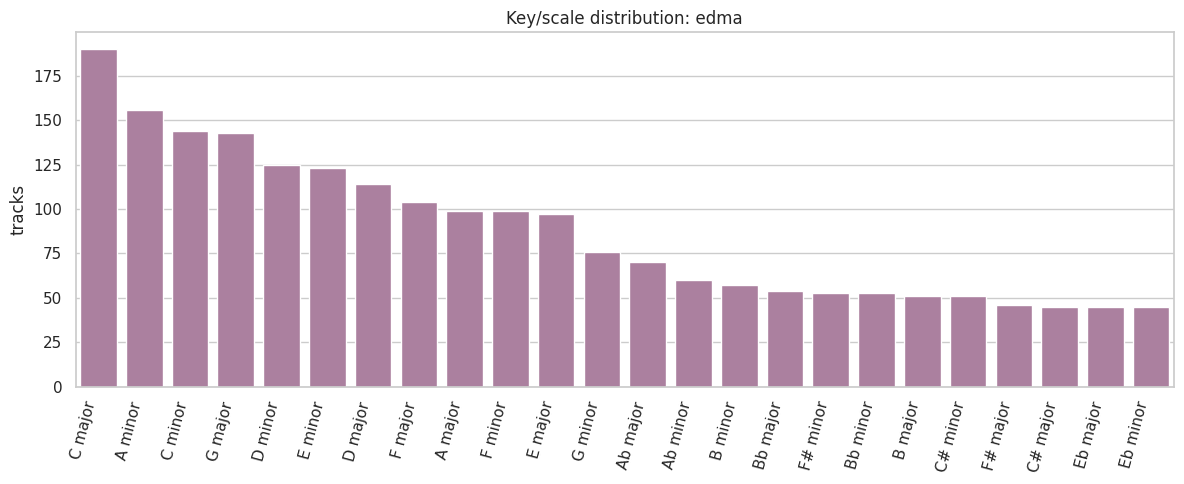

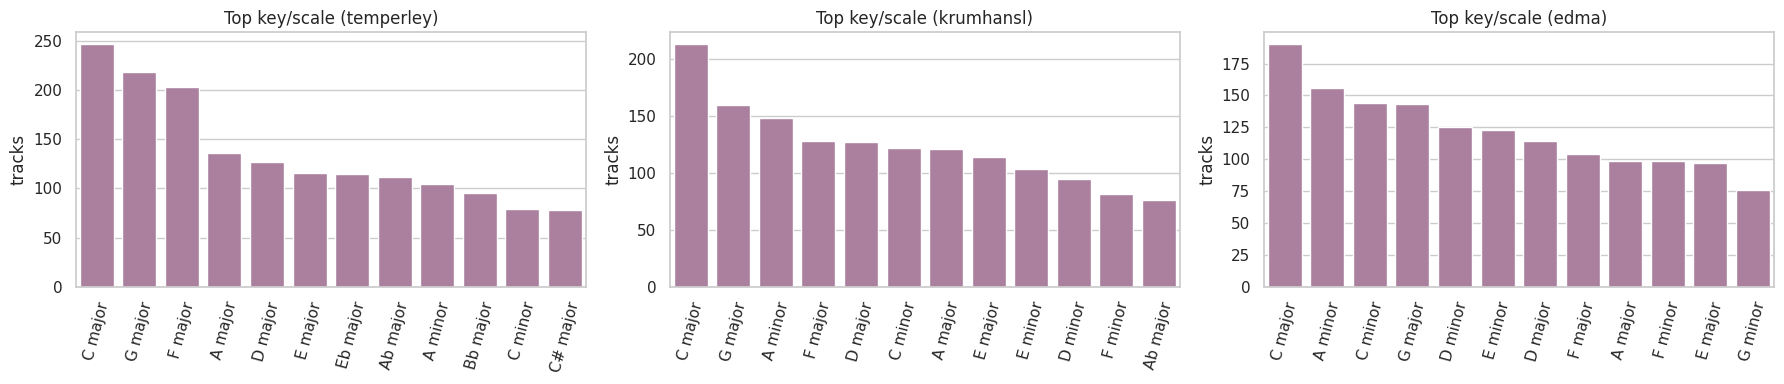

49.095238095238095

In [17]:
profiles = ["temperley", "krumhansl", "edma"]

# One plot per profile (full distribution; can be dense but is faithful).
for p in profiles:
    key_scale = df[f"key_{p}"].astype(str) + " " + df[f"scale_{p}"].astype(str)
    counts = key_scale.value_counts().sort_values(ascending=False)

    plt.figure(figsize=(12, 5))
    sns.barplot(x=counts.index, y=counts.values, color="#B279A2")
    plt.xticks(rotation=75, ha="right")
    plt.title(f"Key/scale distribution: {p}")
    plt.ylabel("tracks")
    plt.xlabel("")
    plt.tight_layout()
    plt.show()

# Combined overview (compact): top 12 key/scale labels per profile.
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, p in enumerate(profiles):
    key_scale = df[f"key_{p}"].astype(str) + " " + df[f"scale_{p}"].astype(str)
    counts = key_scale.value_counts().head(12)
    sns.barplot(x=counts.index, y=counts.values, ax=axes[i], color="#B279A2")
    axes[i].set_title(f"Top key/scale ({p})")
    axes[i].tick_params(axis="x", rotation=75)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("tracks")

plt.tight_layout()
plt.show()

# Agreement across all three profiles.
all_agree = (
    (df["key_temperley"] == df["key_krumhansl"]) &
    (df["key_temperley"] == df["key_edma"]) &
    (df["scale_temperley"] == df["scale_krumhansl"]) &
    (df["scale_temperley"] == df["scale_edma"])
)
agreement_pct = 100 * all_agree.mean()
agreement_pct

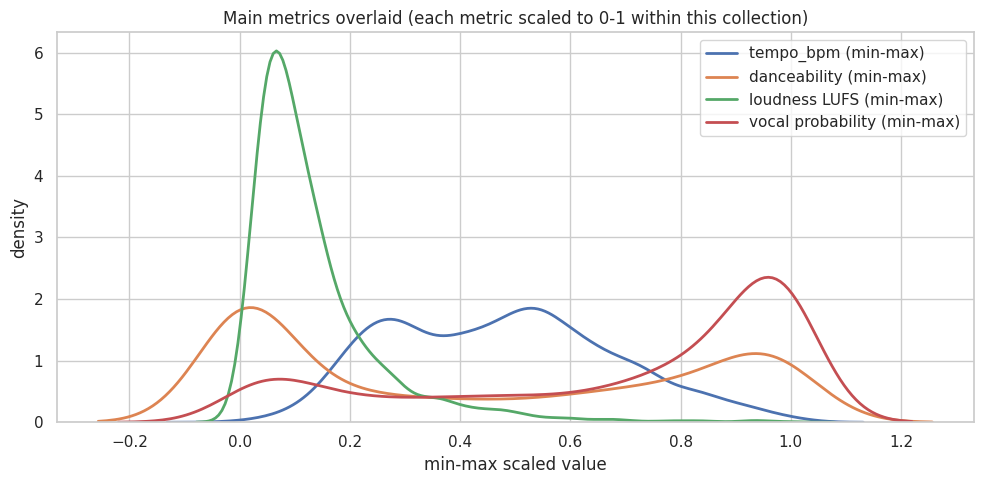

In [18]:
def minmax01(x: pd.Series) -> pd.Series:
    x = pd.to_numeric(x, errors="coerce")
    lo = np.nanmin(x.to_numpy(dtype=float))
    hi = np.nanmax(x.to_numpy(dtype=float))
    if not np.isfinite(lo) or not np.isfinite(hi) or hi == lo:
        return pd.Series(np.nan, index=x.index)
    return (x - lo) / (hi - lo)


metrics = pd.DataFrame(
    {
        "tempo_bpm (min-max)": minmax01(df["tempo_bpm"]),
        "danceability (min-max)": minmax01(df["danceability"]),
        "loudness LUFS (min-max)": minmax01(df["loudness_lufs"]),
        "vocal probability (min-max)": minmax01(df["vocal_prob"]),
    }
)

plt.figure(figsize=(10, 5))
for col in metrics.columns:
    sns.kdeplot(metrics[col].dropna(), linewidth=2, label=col)

plt.title("Main metrics overlaid (each metric scaled to 0-1 within this collection)")
plt.xlabel("min-max scaled value")
plt.ylabel("density")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


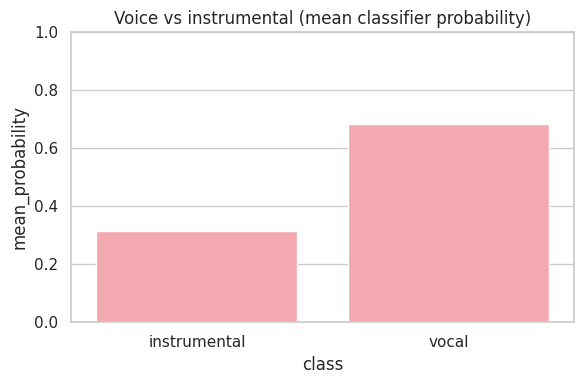

,class,mean_probability
0,instrumental,0.315623
1,vocal,0.684377


In [19]:
voice_summary = pd.DataFrame(
    {
        "class": ["instrumental", "vocal"],
        "mean_probability": [df["instrumental_prob"].mean(), df["vocal_prob"].mean()],
    }
)

plt.figure(figsize=(6, 4))
sns.barplot(data=voice_summary, x="class", y="mean_probability", color="#FF9DA6")
plt.title("Voice vs instrumental (mean classifier probability)")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

voice_summary

In [20]:
# Pairwise key/scale agreement by profile.
def pair_agreement(a: str, b: str) -> float:
    return 100 * (
        (df[f"key_{a}"] == df[f"key_{b}"]) &
        (df[f"scale_{a}"] == df[f"scale_{b}"])
    ).mean()

pairwise = pd.DataFrame(
    {
        "pair": ["temperley vs krumhansl", "temperley vs edma", "krumhansl vs edma"],
        "agreement_pct": [
            pair_agreement("temperley", "krumhansl"),
            pair_agreement("temperley", "edma"),
            pair_agreement("krumhansl", "edma"),
        ],
    }
)

pairwise

,pair,agreement_pct
0,temperley vs krumhansl,57.857143
1,temperley vs edma,51.857143
2,krumhansl vs edma,81.952381


## Observations

- **Styles and genre diversity**: the broad-genre and top-style plots show whether the collection is concentrated or spread across many groups. Use the TSV (`analysis/report/styles_distribution.tsv`) for full style-level detail.
- **Tempo and danceability**: inspect skewness and multimodality in both histograms. A wide spread and multiple peaks indicate mixed musical use cases.
- **Tonality**: compare the three key-profile distributions and the agreement values. If one profile is needed for user-facing output, prefer the one with stronger pairwise agreement and stable distribution shape.
- **Profile agreement**: `all three agree` is reported in `agreement_pct`; pairwise agreements are shown in `pairwise`.
- **Loudness**: integrated LUFS distribution can be compared with typical contemporary mastering ranges. Extreme right tails (very loud values) may indicate clipping-limited masters or analysis edge cases.
- **Voice vs instrumental**: the mean class probabilities summarize the collection tendency; if needed, convert to hard labels with a threshold (for example `vocal_prob >= 0.5`).


In [21]:
recommended_profile = pairwise.set_index("pair")["agreement_pct"]
profile_votes = {
    "temperley": (pair_agreement("temperley", "krumhansl") + pair_agreement("temperley", "edma")) / 2,
    "krumhansl": (pair_agreement("temperley", "krumhansl") + pair_agreement("krumhansl", "edma")) / 2,
    "edma": (pair_agreement("temperley", "edma") + pair_agreement("krumhansl", "edma")) / 2,
}
selected_profile = max(profile_votes, key=profile_votes.get)

summary = {
    "num_tracks": int(num_tracks),
    "num_styles": int(style_dim),
    "top10_broad_genres": broad_counts.head(10).to_dict(orient="records"),
    "all_three_key_agreement_pct": round(float(agreement_pct), 2),
    "pairwise_key_agreement_pct": {k: round(float(v), 2) for k, v in zip(pairwise["pair"], pairwise["agreement_pct"])},
    "recommended_single_profile": selected_profile,
    "tempo_mean_bpm": round(float(df["tempo_bpm"].mean()), 2),
    "tempo_std_bpm": round(float(df["tempo_bpm"].std()), 2),
    "danceability_mean": round(float(df["danceability"].mean()), 3),
    "loudness_mean_lufs": round(float(df["loudness_lufs"].mean()), 2),
    "vocal_probability_mean": round(float(df["vocal_prob"].mean()), 3),
}

summary

{'num_tracks': 2100,
 'num_styles': 400,
 'top10_broad_genres': [{'broad_genre': 'Rock', 'tracks': 549},
  {'broad_genre': 'Electronic', 'tracks': 463},
  {'broad_genre': 'Hip Hop', 'tracks': 271},
  {'broad_genre': 'Folk, World, & Country', 'tracks': 204},
  {'broad_genre': 'Pop', 'tracks': 155},
  {'broad_genre': 'Latin', 'tracks': 117},
  {'broad_genre': 'Classical', 'tracks': 86},
  {'broad_genre': 'Funk / Soul', 'tracks': 64},
  {'broad_genre': 'Jazz', 'tracks': 56},
  {'broad_genre': 'Reggae', 'tracks': 40}],
 'all_three_key_agreement_pct': 49.1,
 'pairwise_key_agreement_pct': {'temperley vs krumhansl': 57.86,
  'temperley vs edma': 51.86,
  'krumhansl vs edma': 81.95},
 'recommended_single_profile': 'krumhansl',
 'tempo_mean_bpm': 119.14,
 'tempo_std_bpm': 25.16,
 'danceability_mean': 0.418,
 'loudness_mean_lufs': 2.8,
 'vocal_probability_mean': 0.684}